In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from protocols import utils, graphs
from scipy.stats import norm

plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['figure.figsize'] = (6.69, 5.02)
plt.rcParams['font.size'] =7 

%load_ext autoreload
%autoreload 2

# Methods notebook

This notebook provides an overview of  The Training Set and The Validation Set, derived from version 3.4.0 of the CRyPTIC Dataset.

The code used to generate the method schematic is also ehre.

The training set is the sample set used to build the WHOv1 catalogue (cryptic v1.0.0).

The validation set are the samples collected since then (v3.4.0 - v1.0.0)

## Load in data

In [2]:
v3_pheno = pd.read_parquet('data/cryptic-tables-v3.4.0/DST_MEASUREMENTS.parquet').reset_index()
v3_geno = pd.read_parquet('data/cryptic-tables-v3.4.0/GENOMES.parquet').reset_index()
crypticv3 = pd.read_parquet('data/cryptic-tables-v3.4.0/WGS_SAMPLES.parquet').reset_index()
crypticv3 = crypticv3[crypticv3.in_final_tables]
validation = crypticv3[crypticv3.dataset=='CRyPTIC-v1.0']


##  Training Data

In [3]:
#filter for training set | remove low quality phenos | filter for drugs etc
training = crypticv3[crypticv3.dataset=='CRyPTIC-v1.0']
phenotypes = v3_pheno[v3_pheno.UNIQUEID.isin(training.UNIQUEID.unique())]
phenotypes = phenotypes[~phenotypes.DRUG.isin([ 'MPM','CYC','IMI','DCS','GEN','GFX','CLR', 'OFX', 'PAS', 'CIP', 'RFB', 'PTO'])]
phenotypes = phenotypes[phenotypes.QUALITY!='LOW']
phenotypes = phenotypes.groupby(["UNIQUEID", "DRUG"], group_keys=False).apply(utils.filter_multiple_phenos)
phenotypes = phenotypes[phenotypes.PHENOTYPE.isin(['R', 'S'])]

train_table = phenotypes.groupby(["DRUG", "PHENOTYPE"])["UNIQUEID"].nunique().unstack(fill_value=0).rename(columns={"R": "R count", "S": "S count"}).assign(total=lambda d: d["R count"] + d["S count"]).reset_index()
train_table

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_56749/1101782615.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  phenotypes = phenotypes.groupby(["UNIQUEID", "DRUG"], group_keys=False).apply(utils.filter_multiple_phenos)


PHENOTYPE,DRUG,R count,S count,total
0,AMI,1497,17715,19212
1,BDQ,144,11082,11226
2,CAP,956,10582,11538
3,CFZ,451,12293,12744
4,DLM,147,10311,10458
5,EMB,5525,28980,34505
6,ETH,2887,11596,14483
7,INH,13662,23498,37160
8,KAN,1839,16360,18199
9,LEV,2192,9583,11775


Training dataset: 39349 samples


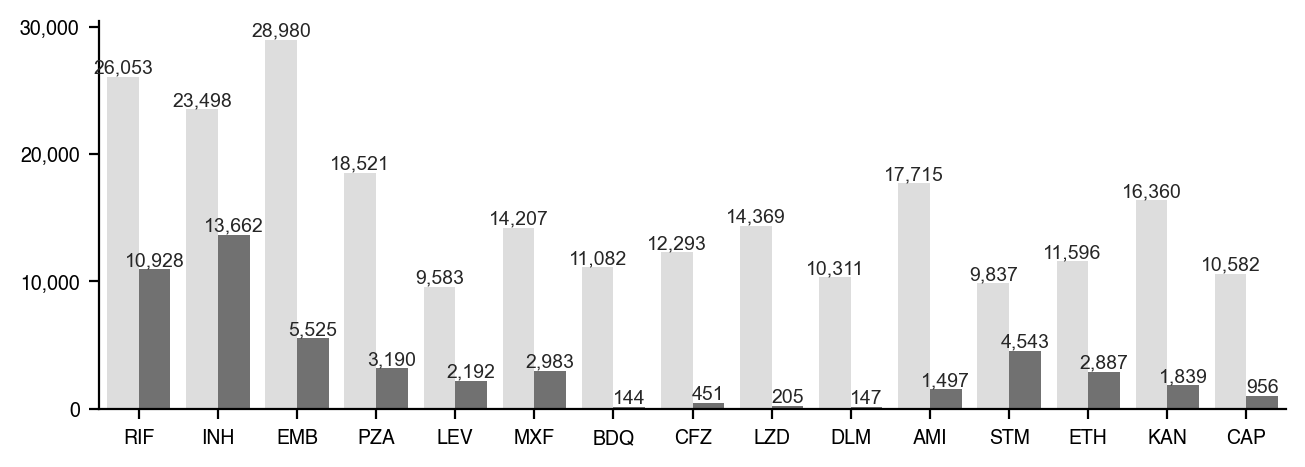

In [5]:
graphs.plot_pheno_counts(phenotypes, 'Training dataset', savefig='figs/data/training_samples.pdf')

##  Validation Data

In [6]:
#filter for validation set | remove low quality phenos | filter for drugs etc
validation = crypticv3[crypticv3.dataset!='CRyPTIC-v1.0']
val_phenotypes = v3_pheno[v3_pheno.UNIQUEID.isin(validation.UNIQUEID.unique())]
val_phenotypes = val_phenotypes[~val_phenotypes.DRUG.isin([ 'MPM','CYC','IMI','DCS','GEN','GFX','CLR', 'thioacetazone', 'TZE', 'CIP', 'RFB', 'OFX', 'PAS', 'PTO'])]
val_phenotypes = val_phenotypes[val_phenotypes.QUALITY!='LOW']
val_phenotypes = val_phenotypes.groupby(["UNIQUEID", "DRUG"], group_keys=False).apply(utils.filter_multiple_phenos)
val_phenotypes = val_phenotypes[val_phenotypes.PHENOTYPE.isin(['R', 'S'])]

val_table = val_phenotypes.groupby(["DRUG", "PHENOTYPE"])["UNIQUEID"].nunique().unstack(fill_value=0).rename(columns={"R": "R count", "S": "S count"}).assign(total=lambda d: d["R count"] + d["S count"]).reset_index()
val_table

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_56749/1895914233.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_phenotypes = val_phenotypes.groupby(["UNIQUEID", "DRUG"], group_keys=False).apply(utils.filter_multiple_phenos)


PHENOTYPE,DRUG,R count,S count,total
0,AMI,742,7062,7804
1,BDQ,838,3476,4314
2,CAP,595,5461,6056
3,CFZ,106,3476,3582
4,DLM,44,2789,2833
5,EMB,2033,5003,7036
6,ETH,1053,3806,4859
7,INH,5225,6155,11380
8,KAN,991,7029,8020
9,LEV,466,2979,3445


Validation dataset: 14380 samples


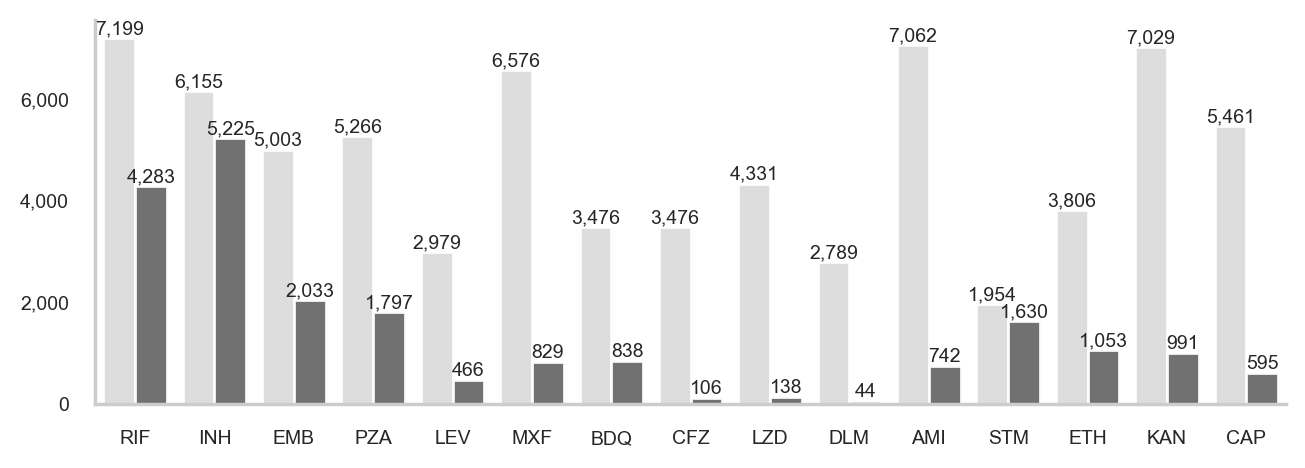

In [7]:
graphs.plot_pheno_counts(val_phenotypes, 'Validation dataset', savefig='figs/data/validation_samples.pdf')

In [8]:
combined_table = train_table.merge(val_table, on="DRUG", suffixes=(" (train)", " (val)"))
combined_table

PHENOTYPE,DRUG,R count (train),S count (train),total (train),R count (val),S count (val),total (val)
0,AMI,1497,17715,19212,742,7062,7804
1,BDQ,144,11082,11226,838,3476,4314
2,CAP,956,10582,11538,595,5461,6056
3,CFZ,451,12293,12744,106,3476,3582
4,DLM,147,10311,10458,44,2789,2833
5,EMB,5525,28980,34505,2033,5003,7036
6,ETH,2887,11596,14483,1053,3806,4859
7,INH,13662,23498,37160,5225,6155,11380
8,KAN,1839,16360,18199,991,7029,8020
9,LEV,2192,9583,11775,466,2979,3445


# Schematic of Univariate Binomial Method

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_56749/2060489527.py:49: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


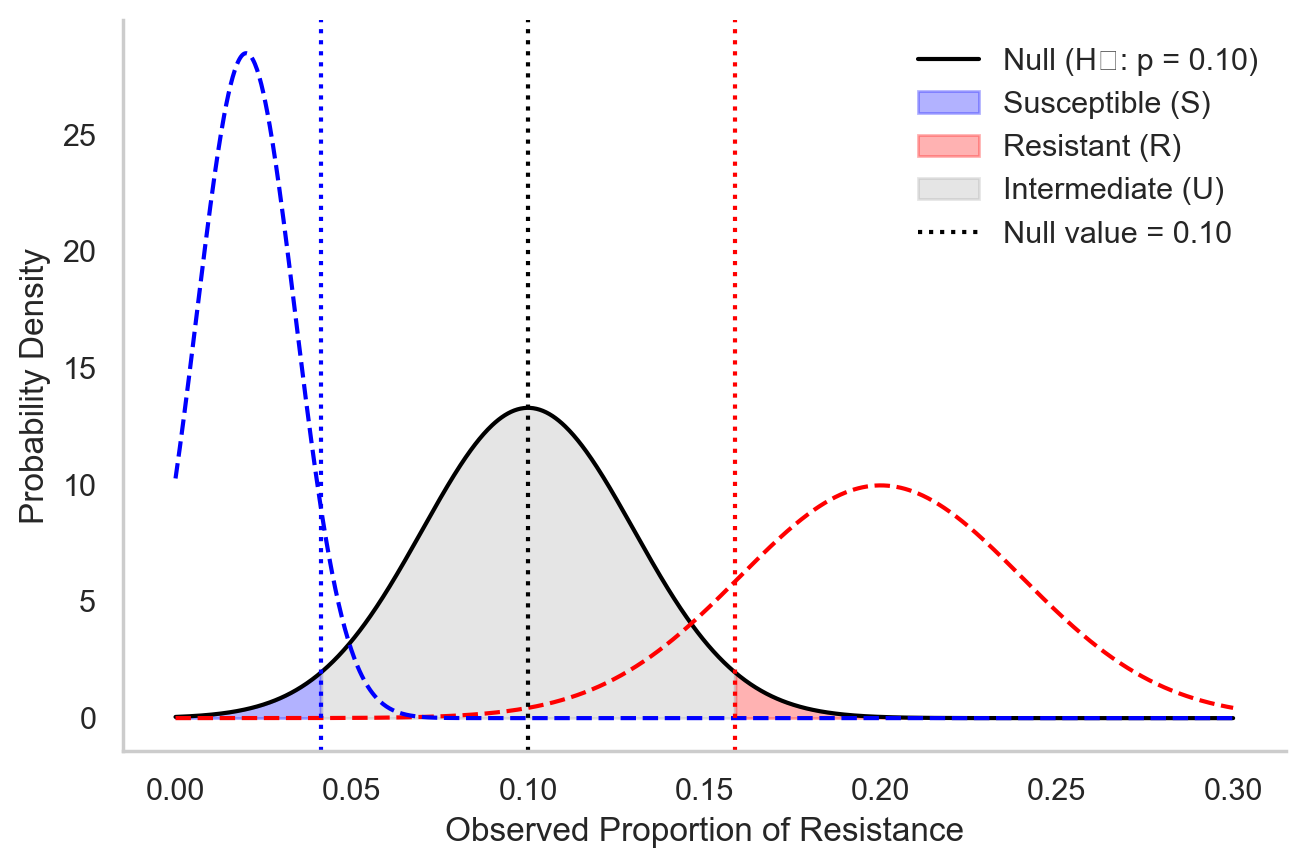

In [9]:


# Parameters
p_null = 0.10
n = 100
alpha = 0.05
se_null = np.sqrt(p_null * (1 - p_null) / n)

# Critical values
z_crit = norm.ppf(1 - alpha / 2)
ci_lower = p_null - z_crit * se_null
ci_upper = p_null + z_crit * se_null

# Hypothetical alternatives
p_resistant = 0.20
p_susceptible = 0.02
se_r = np.sqrt(p_resistant * (1 - p_resistant) / n)
se_s = np.sqrt(p_susceptible * (1 - p_susceptible) / n)

# X values and distributions
x = np.linspace(0, 0.3, 1000)
y_null = norm.pdf(x, p_null, se_null)
y_r = norm.pdf(x, p_resistant, se_r)
y_s = norm.pdf(x, p_susceptible, se_s)

# Plot
fig, ax = plt.subplots(figsize=(6.69, 4.5))

ax.plot(x, y_null, color='black', label='Null (H₀: p = 0.10)')
ax.plot(x, y_r, color='red', linestyle='--')
ax.plot(x, y_s, color='blue', linestyle='--')

ax.fill_between(x, y_null, where=(x < ci_lower), color='blue', alpha=0.3, label='Susceptible (S)')
ax.fill_between(x, y_null, where=(x > ci_upper), color='red', alpha=0.3, label='Resistant (R)')
ax.fill_between(x, y_null, where=(x >= ci_lower) & (x <= ci_upper), color='gray', alpha=0.2, label='Intermediate (U)')

ax.axvline(ci_lower, color='blue', linestyle=':')
ax.axvline(p_null, color='black', linestyle=':', label='Null value = 0.10')
ax.axvline(ci_upper, color='red', linestyle=':')

# Labels
ax.set_xlabel('Observed Proportion of Resistance')
ax.set_ylabel('Probability Density')

# Style adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

legend = ax.legend(frameon=False)
plt.tight_layout()
plt.show()


/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_56749/2924898403.py:60: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


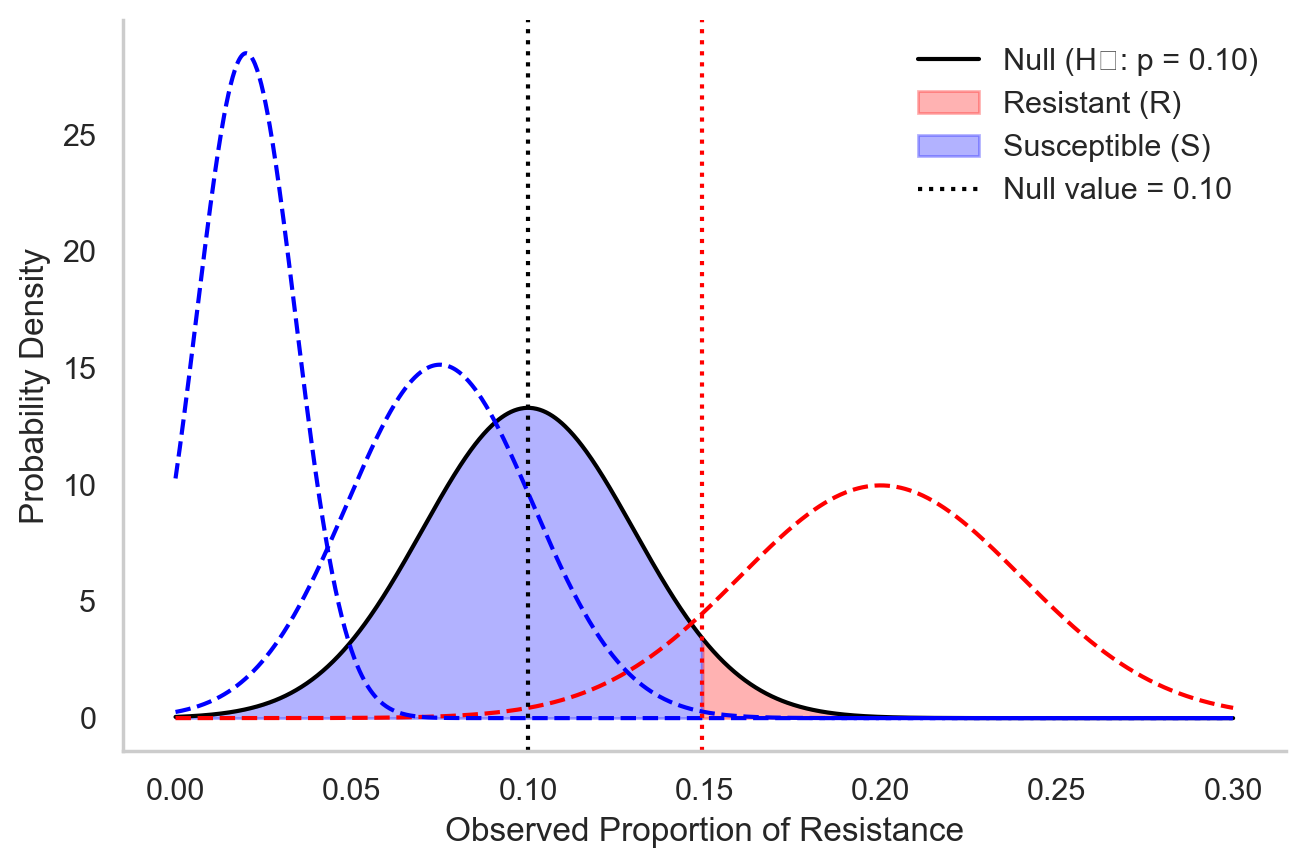

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
p_null = 0.10
n = 100
alpha = 0.05
se_null = np.sqrt(p_null * (1 - p_null) / n)

# One-tailed critical value (right-tailed test)
z_crit = norm.ppf(1 - alpha)
ci_upper = p_null + z_crit * se_null

# Hypothetical alternatives
p_resistant = 0.20
p_susceptible_1 = 0.02
p_susceptible_2 = 0.075
se_r = np.sqrt(p_resistant * (1 - p_resistant) / n)
se_s1 = np.sqrt(p_susceptible_1 * (1 - p_susceptible_1) / n)
se_s2 = np.sqrt(p_susceptible_2 * (1 - p_susceptible_2) / n)

# X values and distributions
x = np.linspace(0, 0.3, 1000)
y_null = norm.pdf(x, p_null, se_null)
y_r = norm.pdf(x, p_resistant, se_r)
y_s1 = norm.pdf(x, p_susceptible_1, se_s1)
y_s2 = norm.pdf(x, p_susceptible_2, se_s2)

# Plot
fig, ax = plt.subplots(figsize=(6.69, 4.5))

# Main curves
ax.plot(x, y_null, color='black', label='Null (H₀: p = 0.10)')
ax.plot(x, y_r, color='red', linestyle='--')

# Just one legend entry for both susceptible examples
ax.plot(x, y_s1, color='blue', linestyle='--')
ax.plot(x, y_s2, color='blue', linestyle='--')  # No label for this one

# Shading for classification
ax.fill_between(x, y_null, where=(x > ci_upper), color='red', alpha=0.3, label='Resistant (R)')
ax.fill_between(x, y_null, where=(x <= ci_upper), color='blue', alpha=0.3, label='Susceptible (S)')

# Vertical lines
ax.axvline(ci_upper, color='red', linestyle=':')
ax.axvline(p_null, color='black', linestyle=':', label='Null value = 0.10')

# Labels
ax.set_xlabel('Observed Proportion of Resistance')
ax.set_ylabel('Probability Density')

# Style adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Legend
legend = ax.legend(frameon=False)
plt.tight_layout()
plt.show()
